In [1]:
!pip install -q kaggle transformers datasets scikit-learn

from google.colab import files
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d vijaydevane/blooms-taxonomy-dataset
!unzip -o blooms-taxonomy-dataset.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/vijaydevane/blooms-taxonomy-dataset
License(s): apache-2.0
100% 240k/240k [00:00<00:00, 418kB/s]

Archive:  blooms-taxonomy-dataset.zip
  inflating: blooms_taxonomy_dataset.csv  


In [2]:
import pandas as pd

df = pd.read_csv("blooms_taxonomy_dataset.csv")
print(df.head())
print(df.columns)
print(df.iloc[:,-1].value_counts())

                                           Questions Category
0  About what proportion of the population of the...      BT1
1  Correctly label the brain lobes indicated on t...      BT1
2                          Define compound interest.      BT1
3                  Define four types of traceability      BT1
4                               Define mercantilism.      BT1
Index(['Questions', 'Category'], dtype='object')
Category
BT1    2582
BT2    1801
BT3    1508
BT4    1293
BT6     800
BT5     783
Name: count, dtype: int64


In [3]:
import pandas as pd

df = pd.read_csv("blooms_taxonomy_dataset.csv")
df = df.dropna(subset=['Questions', 'Category']).reset_index(drop=True)

print(df.head())
print(df['Category'].value_counts())

                                           Questions Category
0  About what proportion of the population of the...      BT1
1  Correctly label the brain lobes indicated on t...      BT1
2                          Define compound interest.      BT1
3                  Define four types of traceability      BT1
4                               Define mercantilism.      BT1
Category
BT1    2582
BT2    1801
BT3    1508
BT4    1293
BT6     800
BT5     783
Name: count, dtype: int64


In [4]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english')) - {
    'define','explain','describe','identify','apply','analyze',
    'evaluate','create','compare','design','list','discuss',
    'label','correctly','proportion'
}

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return " ".join(tokens)

df['clean_question'] = df['Questions'].apply(clean_text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [5]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

le = LabelEncoder()
df['label'] = le.fit_transform(df['Category'])

print(dict(zip(le.classes_, le.transform(le.classes_))))

X_train, X_test, y_train, y_test = train_test_split(
    df['clean_question'], df['label'], test_size=0.2,
    stratify=df['label'], random_state=42
)

class_weights = compute_class_weight(
    class_weight='balanced', classes=np.unique(y_train), y=y_train
)
class_weight_dict = dict(enumerate(class_weights))
print(class_weight_dict)

{'BT1': np.int64(0), 'BT2': np.int64(1), 'BT3': np.int64(2), 'BT4': np.int64(3), 'BT5': np.int64(4), 'BT6': np.int64(5)}
{0: np.float64(0.5657470151661826), 1: np.float64(0.8111265325005783), 2: np.float64(0.9691818684355997), 3: np.float64(1.1303997421018697), 4: np.float64(1.8671458998935038), 5: np.float64(1.8263020833333334)}


In [6]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional, SpatialDropout1D
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

MAX_WORDS = 8000
MAX_LEN = 30

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=MAX_LEN)
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(X_test), maxlen=MAX_LEN)

num_classes = len(le.classes_)

model = Sequential([
    Embedding(MAX_WORDS, 64),
    SpatialDropout1D(0.3),
    Bidirectional(LSTM(32, kernel_regularizer=l2(1e-4))),
    Dropout(0.6),
    Dense(32, activation='relu', kernel_regularizer=l2(1e-4)),
    Dropout(0.4),
    Dense(num_classes, activation='softmax')
])

model.build(input_shape=(None, MAX_LEN))
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)

history = model.fit(
    X_train_seq, y_train,
    validation_split=0.15,
    epochs=25,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr]
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 30, 64)         │       512,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 30, 64)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 539,110 (2.06 MB)

 Trainable params: 539,110 (2.06 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
187/187 ━━━━━━━━━━━━━━━━━━━━ 17s 39ms/step - accuracy: 0.1691 - loss: 1.8013 - val_accuracy: 0.1046 - val_loss: 1.7813 - learning_rate: 0.0010
Epoch 2/25
187/187 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.3602 - loss: 1.5234 - val_accuracy: 0.5228 - val_loss: 1.2850 - learning_rate: 0.0010
Epoch 3/25
187/187 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.5351 - loss: 1.1180 - val_accuracy: 0.6426 - val_loss: 1.0329 - learning_rate: 0.0010
Epoch 4/25
187/187 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.6536 - loss: 0.8639 - val_accuracy: 0.6549 - val_loss: 1.0100 - learning_rate: 0.0010
Epoch 5/25
187/187 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.7349 - loss: 0.6989 - val_accuracy: 0.6749 - val_loss: 0.9584 - learning_rate: 0.0010
Epoch 6/25
187/187 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.7858 - loss: 0.5697 - val_accuracy: 0.6625 - val_loss: 1.0351 - learning_rate: 0.0010
Epoch 7/25
187/187 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8168 - loss: 0

In [7]:
!pip install -q transformers[torch] accelerate

import torch
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
from transformers import Trainer, TrainingArguments
from torch.utils.data import Dataset

bert_tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

train_enc = bert_tokenizer(list(X_train), truncation=True, padding=True, max_length=32)
test_enc = bert_tokenizer(list(X_test), truncation=True, padding=True, max_length=32)

class BloomDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = list(labels)
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

train_dataset = BloomDataset(train_enc, y_train.values)
test_dataset = BloomDataset(test_enc, y_test.values)

bert_model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', num_labels=num_classes
)

class_weights_tensor = torch.tensor(class_weights, dtype=torch.float)

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fct = torch.nn.CrossEntropyLoss(weight=class_weights_tensor.to(logits.device))
        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss

training_args = TrainingArguments(
    output_dir="./bert_bloom",
    num_train_epochs=4,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    eval_strategy="epoch",
    save_strategy="no",
    logging_steps=50,
    learning_rate=2e-5,
)

trainer = WeightedTrainer(
    model=bert_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
)

trainer.train()

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss
1,0.845267,0.716416
2,0.604796,0.612761
3,0.384101,0.607190
4,0.423325,0.588099


TrainOutput(global_step=1756, training_loss=0.6366636675691278, metrics={'train_runtime': 107.4774, 'train_samples_per_second': 261.004, 'train_steps_per_second': 16.338, 'total_flos': 232265033980416.0, 'train_loss': 0.6366636675691278, 'epoch': 4.0})

55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
              precision    recall  f1-score   support

         BT1       0.68      0.72      0.70       516
         BT2       0.59      0.60      0.60       360
         BT3       0.69      0.69      0.69       302
         BT4       0.57      0.51      0.54       259
         BT5       0.81      0.83      0.82       157
         BT6       0.89      0.82      0.85       160

    accuracy                           0.68      1754
   macro avg       0.70      0.70      0.70      1754
weighted avg       0.68      0.68      0.68      1754



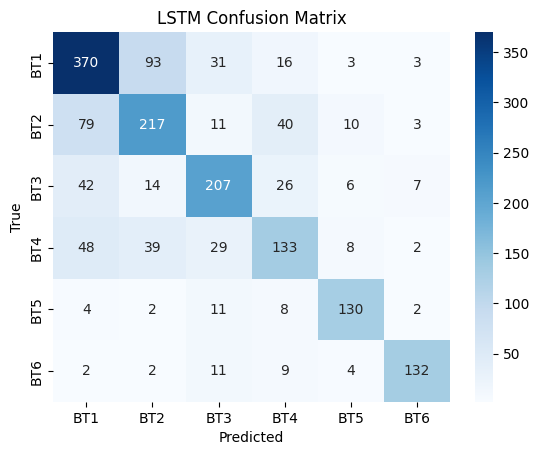

In [8]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = np.argmax(model.predict(X_test_seq), axis=1)
print(classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('LSTM Confusion Matrix')
plt.show()

              precision    recall  f1-score   support

         BT1       0.74      0.76      0.75       516
         BT2       0.70      0.70      0.70       360
         BT3       0.82      0.81      0.82       302
         BT4       0.77      0.69      0.73       259
         BT5       0.88      0.93      0.90       157
         BT6       0.89      0.94      0.91       160

    accuracy                           0.78      1754
   macro avg       0.80      0.80      0.80      1754
weighted avg       0.78      0.78      0.78      1754



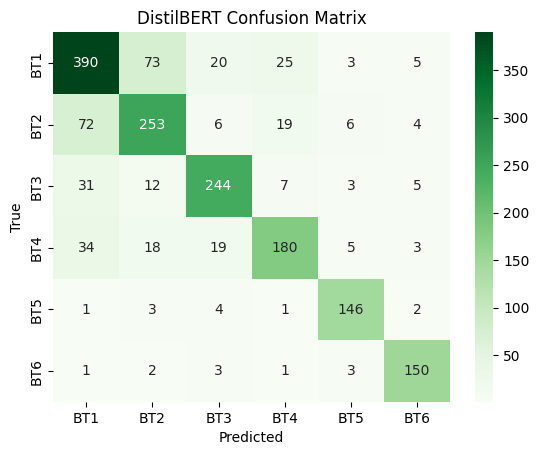

In [9]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

preds_output = trainer.predict(test_dataset)
y_pred_bert = np.argmax(preds_output.predictions, axis=1)

print(classification_report(y_test, y_pred_bert, target_names=le.classes_))

cm_bert = confusion_matrix(y_test, y_pred_bert)
sns.heatmap(cm_bert, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Greens')
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('DistilBERT Confusion Matrix')
plt.show()

In [10]:
import pandas as pd

# ---- For DistilBERT (PyTorch) ----
preds_output = trainer.predict(test_dataset)
y_pred_bert = np.argmax(preds_output.predictions, axis=1)

results_df = pd.DataFrame({
    'Question': X_test.values,
    'Actual': le.inverse_transform(y_test.values),
    'Predicted': le.inverse_transform(y_pred_bert),
})
results_df['Correct'] = results_df['Actual'] == results_df['Predicted']

# Overall accuracy check
print(f"Correct: {results_df['Correct'].sum()} / {len(results_df)}")
print(f"Accuracy: {results_df['Correct'].mean():.4f}")

# Show a sample of predictions
print("\n--- Sample predictions ---")
print(results_df.sample(15, random_state=1).to_string(index=False))

# Show ONLY the wrong ones — most useful for error analysis
print("\n--- Misclassified examples ---")
wrong_df = results_df[~results_df['Correct']]
print(wrong_df.head(20).to_string(index=False))

# Which BT levels get confused with which — most common error pairs
print("\n--- Most common confusion pairs (Actual -> Predicted) ---")
print(wrong_df.groupby(['Actual', 'Predicted']).size().sort_values(ascending=False).head(10))

Correct: 1363 / 1754
Accuracy: 0.7771

--- Sample predictions ---
                                                                                                                                          Question Actual Predicted  Correct
                                                                                               use dijkstras algorithm find shortest path z figure    BT3       BT3     True
                                                                                                                        state find word dictionary    BT1       BT1     True
plan strategy implementing continuous integration continuous deployment cicd pipeline accelerating software delivery agile development environment    BT6       BT6     True
                                                                                                                       bag contains white red ball    BT1       BT3    False
                                                                     

In [11]:
y_pred_lstm = np.argmax(model.predict(X_test_seq), axis=1)

results_lstm_df = pd.DataFrame({
    'Question': X_test.values,
    'Actual': le.inverse_transform(y_test.values),
    'Predicted': le.inverse_transform(y_pred_lstm),
})
results_lstm_df['Correct'] = results_lstm_df['Actual'] == results_lstm_df['Predicted']

print(f"Correct: {results_lstm_df['Correct'].sum()} / {len(results_lstm_df)}")
print(f"Accuracy: {results_lstm_df['Correct'].mean():.4f}")

wrong_lstm_df = results_lstm_df[~results_lstm_df['Correct']]
print("\n--- Misclassified examples (LSTM) ---")
print(wrong_lstm_df.head(20).to_string(index=False))

print("\n--- Most common confusion pairs (LSTM) ---")
print(wrong_lstm_df.groupby(['Actual', 'Predicted']).size().sort_values(ascending=False).head(10))

55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
Correct: 1189 / 1754
Accuracy: 0.6779

--- Misclassified examples (LSTM) ---
                                                                                                                                                                                     Question Actual Predicted  Correct
attempt purify single protein x complex mixture protein protein x large number aspartic glutamic acid residue lysine arginine histidine residue suggest explain method elute protein x column    BT6       BT4    False
                                                                                                                  derive expression sag case overhead transmission line support unequal level    BT3       BT4    False
                                                                                                               define indegree outdegree vertex graph find indegree outdegree following graph    BT1       BT3    False
                   

In [13]:
device = next(bert_model.parameters()).device  # detect wherever the model currently lives (cuda or cpu)

def predict_bloom_level(question, use_model='bert'):
    cleaned = clean_text(question)

    if use_model == 'bert':
        enc = bert_tokenizer([cleaned], truncation=True, padding=True, max_length=32, return_tensors="pt")
        enc = {k: v.to(device) for k, v in enc.items()}   # move inputs to same device as model
        with torch.no_grad():
            output = bert_model(**enc)
        pred = torch.argmax(output.logits, dim=1).item()
    else:  # lstm
        seq = pad_sequences(tokenizer.texts_to_sequences([cleaned]), maxlen=MAX_LEN)
        pred = np.argmax(model.predict(seq), axis=1)[0]

    return le.inverse_transform([pred])[0]

# Try it
print(predict_bloom_level("Design a new algorithm to optimize memory usage.", use_model='bert'))
print(predict_bloom_level("Define what a variable is in programming.", use_model='bert'))
print(predict_bloom_level("Compare the efficiency of two sorting algorithms.", use_model='lstm'))

BT6
BT1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step
BT5
